# 01 — Echo State Network on Iris (random reservoirs)

Tutorial: classify Iris by feeding each flower's 4 features as sine-encoded time series into a **frozen random reservoir** (`reservoirs.random`) and training only a ridge readout. Pick the connectivity with a single variable; this consolidates the old `handson_*` notebooks (fully-connected / ring / gaussian) **and** adds a genuine Erdős–Rényi reservoir.

In [1]:
import sys, os
from pathlib import Path
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); os.chdir(REPO)
print('repo root set:', REPO.name)   # name only, no absolute path

repo root set: ESN-unofficial-1-utilizzando-matrici-random-con-iris


In [2]:
import numpy as np, pandas as pd, random
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0))
data_raw = df.to_numpy().astype(float)
rng = random.Random(7)
sample = lambda a, b: rng.sample(range(a, b), 40)
train_idxs = sample(0,50)+sample(50,100)+sample(100,150)
test_idxs = [i for i in range(150) if i not in train_idxs]
data = data_raw.copy()
data[:, :4] = data[:, :4] / data[train_idxs, :4].max(axis=0)
timesteps = np.arange(0, 50, 0.5)   # 100 steps (raise resolution -> higher accuracy, slower)
u = np.array([np.vstack([np.sin(timesteps*2*np.pi*pt[i]) for i in range(4)]).T for pt in data[:, :4]])
y = np.array([data[:, 4:]] * len(timesteps)).swapaxes(0, 1).astype(float)
u_train, u_test, y_train, y_test = u[train_idxs], u[test_idxs], y[train_idxs], y[test_idxs]
print('iris encoded:', u.shape, '-> classes', y.shape[-1])

iris encoded: (150, 100, 4) -> classes 3


In [3]:
WASHOUT, ALPHA = 10, 1e-4
def collect(res, batch):
    return np.stack([res.forward(seq, collect_states=True) for seq in batch], axis=0)
def ridge(Xs, Ys, washout=WASHOUT, alpha=ALPHA):
    X = Xs[:, washout:, :].reshape(-1, Xs.shape[-1]); Y = Ys[:, washout:, :].reshape(-1, Ys.shape[-1])
    return np.linalg.solve(X.T @ X + alpha*np.eye(X.shape[1]), X.T @ Y)
def series_acc(pred, Yt):
    return float(np.mean(pred.mean(1).argmax(1) == Yt.mean(1).argmax(1)))
def evaluate(res):
    Xtr, Xte = collect(res, u_train), collect(res, u_test)
    w = ridge(Xtr, y_train)
    return series_acc(Xtr @ w, y_train), series_acc(Xte @ w, y_test)

### Compare connectivities
`Reservoir`=fully-connected, `Reservoir2`=ring, `Reservoir3`=gaussian, plus the real sparse `ErdosRenyiReservoir`.

In [4]:
from reservoirs.random import Reservoir, Reservoir2, Reservoir3, ErdosRenyiReservoir
rows = []
for name, make in [
    ('fully_connected', lambda: (np.random.seed(7), Reservoir(4, 100, rhow=1.25))[1]),
    ('ring',            lambda: (np.random.seed(7), Reservoir2(4, 100, rhow=1.25))[1]),
    ('gaussian',        lambda: (np.random.seed(7), Reservoir3(4, 100, rhow=1.25))[1]),
    ('erdos_renyi',     lambda: ErdosRenyiReservoir(4, 100, rhow=1.25, density=0.1, seed=7)),
]:
    tr, te = evaluate(make())
    rows.append({'connectivity': name, 'train_acc': round(tr,3), 'test_acc': round(te,3)})
res = pd.DataFrame(rows); print(res.to_string(index=False)); res

   connectivity  train_acc  test_acc
fully_connected      0.942     0.900
           ring      0.333     0.333
       gaussian      0.933     0.833
    erdos_renyi      0.942     0.867


,connectivity,train_acc,test_acc
0,fully_connected,0.942,0.900
1,ring,0.333,0.333
2,gaussian,0.933,0.833
3,erdos_renyi,0.942,0.867


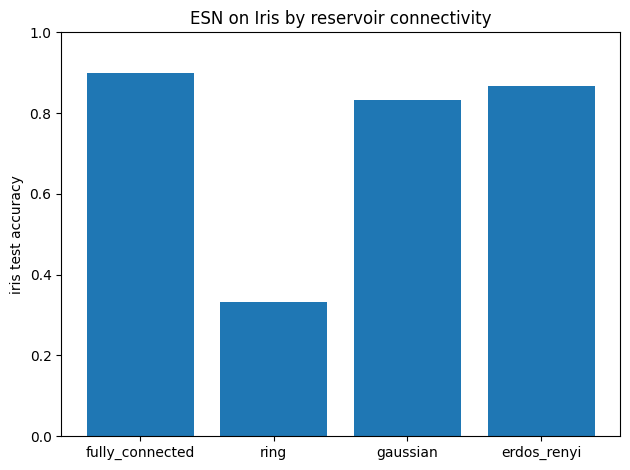

In [5]:
import matplotlib.pyplot as plt
plt.bar(res['connectivity'], res['test_acc']); plt.ylabel('iris test accuracy')
plt.title('ESN on Iris by reservoir connectivity'); plt.ylim(0,1); plt.tight_layout(); plt.show()

**Takeaways:** the bidirectional *ring* reservoir collapses to chance (~0.33) — its purely-oscillatory spectrum is a poor match here; fully-connected / gaussian / Erdős–Rényi all learn. Accuracy rises with more timesteps (`np.arange(0,50,0.1)` → 500 steps) and neurons.